# TDCRPy v2.20.3 vs v2.20.7 — Efficiency comparison

**Fixed free parameter L = 9 keV⁻¹** | **kB = 1×10⁻⁵ cm keV⁻¹** | **V = 10 mL**

Nuclides: **Co-60** (γ emitter), **Sr-90** (pure β), **Cd-109** (EC + X-rays)

Models compared:
- *Analytical* — `modelAnalytical()`, valid for β emitters (Co-60 approximated, Cd-109 N/A)
- *Stochastic* — `TDCRPy()` full Monte Carlo

**Key regression fixed in v2.20.6/2.20.7:**  
`_interact_prompt()` did not propagate `energy_vec_initial` for secondary particles
(Auger electrons, pair-production positrons) — causing `IndexError` in `_quench()`
for any nuclide that produces photons (photoelectric events), i.e. Co-60 and Cd-109.

In [1]:
pip install TDCRPy==2.20.9

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys, os, subprocess, json, tempfile, pathlib, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from importlib.metadata import version
import tdcrpy as td
import tdcrpy.TDCRPy as tm

warnings.filterwarnings('ignore')
print(f'Current TDCRPy version : {version("TDCRPy")}')
print(f'Python                 : {sys.version.split()[0]}')

Current TDCRPy version : 2.20.8
Python                 : 3.13.14


In [3]:
# ── Global parameters ───────────────────────────────────────────────────────
L   = 9.0      # free parameter (keV⁻¹), fixed
kB  = 1.0e-5   # Birks constant (cm keV⁻¹)
V   = 10       # scintillator volume (mL)
N   = 5000     # number of Monte-Carlo trials
ne  = 1000     # quenching discretisation bins (analytical model)

NUCLIDES   = ['Co-60', 'Sr-90', 'Cd-109']
PMF        = ['1',     '1',     '1'     ]
COLORS     = ['#1f77b4', '#ff7f0e', '#2ca02c']   # blue, orange, green
V203       = '2.20.3'
V207       = '2.20.7'

print('Parameters set.')

Parameters set.


## 1. Install v2.20.3 in an isolated directory

In [4]:
TMP_203 = pathlib.Path(tempfile.mkdtemp()) / 'tdcrpy_2203'
TMP_203.mkdir(exist_ok=True)

print(f'Installing TDCRPy=={V203} to {TMP_203} ...')
r = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', f'TDCRPy=={V203}',
     '--target', str(TMP_203), '--quiet', '--no-deps'],
    capture_output=True, text=True
)
if r.returncode == 0:
    print(f'  → TDCRPy {V203} installed successfully.')
else:
    print('  ERROR:', r.stderr[-300:])

Installing TDCRPy==2.20.3 to C:\Users\ROMAIN~1.COU\AppData\Local\Temp\tmp_9rnwhv5\tdcrpy_2203 ...


  → TDCRPy 2.20.3 installed successfully.


In [5]:
def run_v203(script, timeout=480):
    """Run a Python script with TDCRPy 2.20.3 prepended to PYTHONPATH."""
    env = os.environ.copy()
    env['PYTHONPATH'] = str(TMP_203) + os.pathsep + env.get('PYTHONPATH', '')
    full = 'import warnings; warnings.filterwarnings("ignore")\n' + script
    r = subprocess.run(
        [sys.executable, '-c', full],
        capture_output=True, text=True, timeout=timeout, env=env
    )
    return r.stdout.strip(), r.stderr.strip()

# sanity-check
out, _ = run_v203('from importlib.metadata import version; print(version("TDCRPy"))')
print(f'v203 subprocess reports: TDCRPy {out}')

v203 subprocess reports: TDCRPy 2.20.3


## 2. Analytical model — β-spectrum-based (Co-60 approximated, Cd-109 N/A)

In [6]:
ANALYTICAL_SCRIPT = f"""
import json
import tdcrpy.TDCR_model_lib as tl
results = {{}}
for rad in ["Co-60", "Sr-90"]:
    try:
        eff_S, eff_D, eff_T = tl.modelAnalytical(
            {L}, 0, 0, 0, 0, rad, {kB}, {V}, "eff", {ne})
        results[rad] = {{"eff_S": float(eff_S), "eff_D": float(eff_D), "eff_T": float(eff_T)}}
    except Exception as e:
        results[rad] = {{"error": type(e).__name__, "msg": str(e)[:120]}}
print(json.dumps(results))
"""

# ── v2.20.3 ─────────────────────────────────────────────────────────────────
out203, err203 = run_v203(ANALYTICAL_SCRIPT)
try:
    ana_203 = json.loads(out203)
except Exception:
    ana_203 = {}
    print('Parse error 2.20.3:', err203[-300:])

# ── v2.20.7 ─────────────────────────────────────────────────────────────────
ana_207 = {}
for rad in ['Co-60', 'Sr-90']:
    try:
        eff_S, eff_D, eff_T = td.TDCR_model_lib.modelAnalytical(
            L, 0, 0, 0, 0, rad, kB, V, 'eff', ne)
        ana_207[rad] = {'eff_S': float(eff_S), 'eff_D': float(eff_D), 'eff_T': float(eff_T)}
    except Exception as e:
        ana_207[rad] = {'error': type(e).__name__, 'msg': str(e)[:120]}

print('Analytical results collected.')

Analytical results collected.


In [7]:
print(f'\n{"Nuclide":<10} {"Model":<10} {"eff_S":>8} {"eff_D":>8} {"eff_T":>8}  Status')
print('-' * 60)
for rad in ['Co-60', 'Sr-90']:
    for ver, res in [(V203, ana_203), (V207, ana_207)]:
        row = res.get(rad, {})
        if 'error' in row:
            print(f'{rad:<10} {ver:<10} {" ":>8} {" ":>8} {" ":>8}  ⚠ {row["error"]}: {row["msg"][:40]}')
        else:
            print(f'{rad:<10} {ver:<10} {row.get("eff_S",0):>8.5f} {row.get("eff_D",0):>8.5f} {row.get("eff_T",0):>8.5f}  OK')
    print()


Nuclide    Model         eff_S    eff_D    eff_T  Status
------------------------------------------------------------
Co-60      2.20.3      0.99057  0.99153  0.98714  OK
Co-60      2.20.7      0.97969  0.98154  0.96831  OK

Sr-90      2.20.3      0.99504  0.99551  0.99337  OK
Sr-90      2.20.7      0.98974  0.99064  0.98419  OK



## 3. Stochastic model — Full Monte Carlo (N = 5000)

**Expected behaviour for v2.20.3:**
- Co-60 and Cd-109 → `IndexError: list index out of range` in `_quench()` (photoelectric events add secondary particles beyond `energy_vec_initial` length)
- Sr-90 → OK (pure β, no photon interactions)

**v2.20.7:** all three nuclides run correctly.

In [8]:
STOCH_SCRIPT = f"""
import json
import tdcrpy.TDCRPy as tm
results = {{}}
for rad in ["Co-60", "Sr-90", "Cd-109"]:
    try:
        r = tm.TDCRPy({L}, rad, "1", {N}, {kB}, {V})
        results[rad] = {{"eff_S": r[0], "u_eff_S": r[1],
                         "eff_D": r[2], "u_eff_D": r[3],
                         "eff_T": r[4], "u_eff_T": r[5]}}
    except Exception as e:
        results[rad] = {{"error": type(e).__name__, "msg": str(e)[:200]}}
print(json.dumps(results))
"""

print(f'Running stochastic model with v{{V203}} (N={{N}}) — may take several minutes...')
out203s, err203s = run_v203(STOCH_SCRIPT, timeout=600)
try:
    stoch_203 = json.loads(out203s)
    print(f'  v{{V203}} results: {{list(stoch_203.keys())}}')
except Exception:
    stoch_203 = {}
    print('Parse error 2.20.3:', err203s[-400:])

print(f'Done v{{V203}}. Running v{{V207}}...')

stoch_207 = {}
for rad in NUCLIDES:
    try:
        r = tm.TDCRPy(L, rad, '1', N, kB, V)
        stoch_207[rad] = {'eff_S': r[0], 'u_eff_S': r[1],
                          'eff_D': r[2], 'u_eff_D': r[3],
                          'eff_T': r[4], 'u_eff_T': r[5]}
    except Exception as e:
        stoch_207[rad] = {'error': type(e).__name__, 'msg': str(e)[:200]}

print(f'Done v{{V207}}.')

Running stochastic model with v{V203} (N={N}) — may take several minutes...


  v{V203} results: {list(stoch_203.keys())}
Done v{V203}. Running v{V207}...


Done v{V207}.


In [9]:
print(f'\n{"Nuclide":<10} {"Version":<10} {"eff_S":>9} {"u":>7} {"eff_D":>9} {"u":>7} {"eff_T":>9} {"u":>7}  Status')
print('-' * 80)
for rad in NUCLIDES:
    for ver, res in [(V203, stoch_203), (V207, stoch_207)]:
        row = res.get(rad, {})
        if 'error' in row:
            print(f'{rad:<10} {ver:<10} {" ":>9} {" ":>7} {" ":>9} {" ":>7} {" ":>9} {" ":>7}  '
                  f'⚠ {row["error"]}: {row["msg"][:50]}')
        else:
            print(f'{rad:<10} {ver:<10}'
                  f' {row.get("eff_S",0):>9.5f} {row.get("u_eff_S",0):>7.5f}'
                  f' {row.get("eff_D",0):>9.5f} {row.get("u_eff_D",0):>7.5f}'
                  f' {row.get("eff_T",0):>9.5f} {row.get("u_eff_T",0):>7.5f}  OK')
    print()


Nuclide    Version        eff_S       u     eff_D       u     eff_T       u  Status
--------------------------------------------------------------------------------
Co-60      2.20.3       0.99193 0.00111   0.98622 0.00141   0.97573 0.00187  OK
Co-60      2.20.7       0.99096 0.00115   0.98424 0.00151   0.97250 0.00200  OK

Sr-90      2.20.3       0.99390 0.00097   0.98995 0.00123   0.98302 0.00159  OK
Sr-90      2.20.7       0.99512 0.00084   0.99141 0.00112   0.98475 0.00148  OK

Cd-109     2.20.3                                                            ⚠ IndexError: list index out of range
Cd-109     2.20.7       1.81393 0.00517   1.67332 0.00485   1.41044 0.00553  OK



## 4. Comparison plots

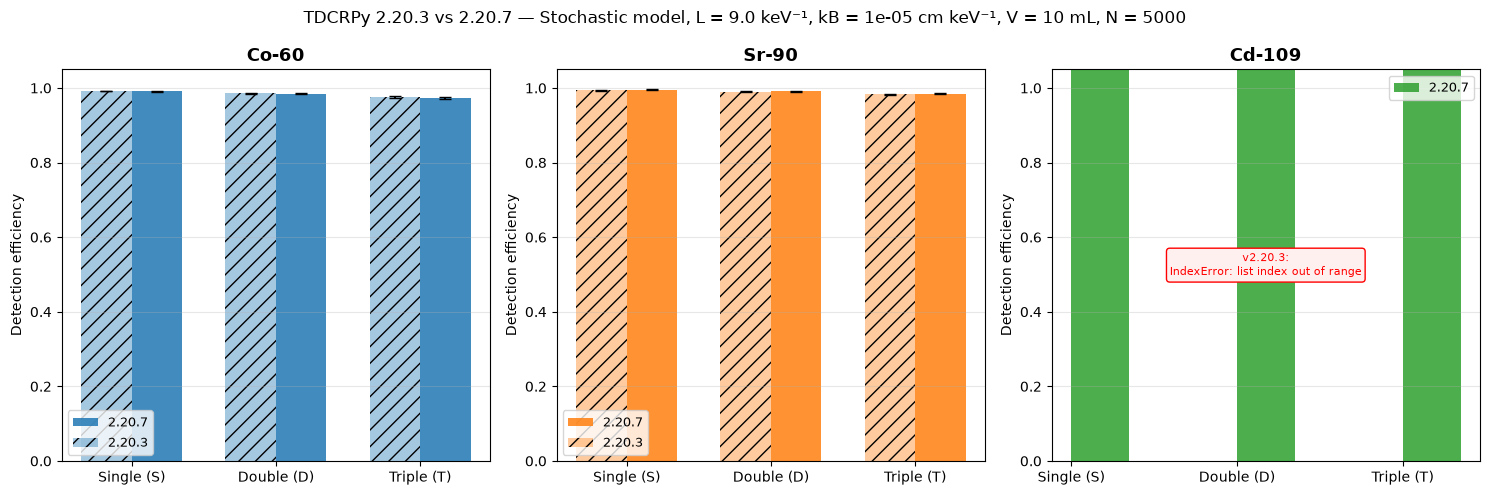

Figure saved as comparison_v2203_v2207.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'TDCRPy {V203} vs {V207} — Stochastic model, L = {L} keV⁻¹, kB = {kB} cm keV⁻¹, V = {V} mL, N = {N}',
             fontsize=12)

eff_labels = ['eff_S', 'eff_D', 'eff_T']
u_labels   = ['u_eff_S', 'u_eff_D', 'u_eff_T']
bar_labels = ['Single (S)', 'Double (D)', 'Triple (T)']
x = np.arange(3)
width = 0.35

for ax, rad, color in zip(axes, NUCLIDES, COLORS):
    row203 = stoch_203.get(rad, {})
    row207 = stoch_207.get(rad, {})

    if 'error' not in row207:
        vals207 = [row207.get(k, 0) for k in eff_labels]
        errs207 = [row207.get(k, 0) for k in u_labels]
        ax.bar(x + width/2, vals207, width, yerr=errs207, capsize=4,
               color=color, alpha=0.85, label=V207)

    if 'error' not in row203:
        vals203 = [row203.get(k, 0) for k in eff_labels]
        errs203 = [row203.get(k, 0) for k in u_labels]
        ax.bar(x - width/2, vals203, width, yerr=errs203, capsize=4,
               color=color, alpha=0.4, hatch='//', label=V203)
    else:
        # Show error annotation instead of bars
        ax.text(0.5, 0.5, f'v{V203}:\n{row203.get("error", "?")}: {row203.get("msg","")[:60]}',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=8, color='red',
                bbox=dict(boxstyle='round', fc='#fff0f0', ec='red'))

    ax.set_title(rad, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels)
    ax.set_ylabel('Detection efficiency')
    ax.set_ylim(0, min(1.05, ax.get_ylim()[1] * 1.1) if 'error' not in row207 else 1.05)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_v2203_v2207.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as comparison_v2203_v2207.png')

## 5. Analytical vs Stochastic — v2.20.7 only

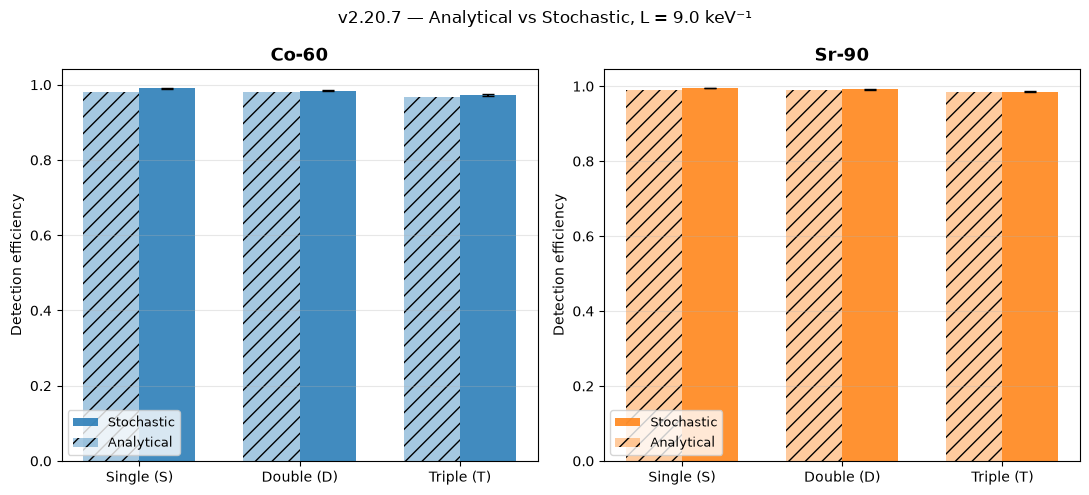

In [11]:
fig2, axes2 = plt.subplots(1, 2, figsize=(11, 5))
fig2.suptitle(f'v{V207} — Analytical vs Stochastic, L = {L} keV⁻¹', fontsize=12)

for ax, rad, color in zip(axes2, ['Co-60', 'Sr-90'], COLORS[:2]):
    row_s = stoch_207.get(rad, {})
    row_a = ana_207.get(rad, {})

    x = np.arange(3)
    width = 0.35

    if 'error' not in row_s:
        vals_s = [row_s.get(k, 0) for k in eff_labels]
        errs_s = [row_s.get(k, 0) for k in u_labels]
        ax.bar(x + width/2, vals_s, width, yerr=errs_s, capsize=4,
               color=color, alpha=0.85, label='Stochastic')

    if 'error' not in row_a:
        vals_a = [row_a.get(k, 0) for k in eff_labels]
        ax.bar(x - width/2, vals_a, width,
               color=color, alpha=0.4, hatch='//', label='Analytical')

    ax.set_title(rad, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels)
    ax.set_ylabel('Detection efficiency')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_analytical_stochastic_v2207.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary

| Nuclide | Model | v2.20.3 | v2.20.7 |
|---------|-------|---------|----------|
| Co-60   | Analytical  | ✓ (β-only approx.) | ✓ (β-only approx.) |
| Co-60   | Stochastic  | **✗ IndexError** | ✓ Fixed |
| Sr-90   | Analytical  | ✓ | ✓ |
| Sr-90   | Stochastic  | ✓ | ✓ |
| Cd-109  | Analytical  | N/A (EC, no β) | N/A (EC, no β) |
| Cd-109  | Stochastic  | **✗ IndexError** | ✓ Fixed |

**Root cause of the regression (introduced in commit `9dbc7496`, v2.20.3–2.20.5):**  
When `_interact_prompt()` was factored out from the inline MC loop, three lines that
updated `energy_vec_initial` were silently dropped:
- `energy_vec_initial[ipart] = e_pe` (photoelectron KE, not photon energy)
- `energy_vec_initial += energie_par_emise_ph` (Auger / X-ray secondaries)

Without those, any photoelectric or pair-production event appended new particles
to `particle_vec` beyond the length of `energy_vec_initial`, crashing `_quench()`
on the next access to `energy_vec_initial[ipart]`.

**Fix in v2.20.6/2.20.7:** `_interact_prompt()` now accepts and returns
`energy_vec_initial`, maintaining it correctly for all secondary particles.